## 03 — MLP com Feature Engineering

Objetivo: testar uma nova versão da MLP incorporando variáveis derivadas de negócio, mantendo o mesmo dataset, random state e lógica de avaliação para comparar com os modelos anteriores.

#### SETUP

In [ ]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt

import joblib
import mlflow
import numpy as np
import pandas as pd
import torch
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
LOG_MLFLOW = False # True apenas ao rodar novos experimentos
SAVE_ARTIFACTS = False # True apenas quando quiser salvar versão oficial
RANDOM_STATE = 555
TEST_SIZE = 0.15
VAL_SIZE = 0.15

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DATA_PATH = Path("../data/processed/churn_clean.csv")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

#### Carregar Dados

In [3]:
df = pd.read_csv(DATA_PATH)

df.shape

(7032, 24)

In [4]:
target = "Churn Value"

drop_cols = ["Country", "State", "City", "Zip Code"]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

#### Feature Engineering

Nesta etapa, criamos variáveis derivadas com base em hipóteses de negócio sobre churn.  
A ideia é facilitar o aprendizado da MLP, fornecendo relações que podem ser difíceis de capturar apenas com as variáveis originais.

As novas features buscam representar:
- intensidade de cobrança;
- tipo de contrato;
- maturidade do cliente;
- nível de engajamento com serviços;
- relação entre preço pago e pacote contratado.

In [5]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    tenure_safe = df["Tenure Months"].replace(0, 1)

    df["avg_charge_per_tenure"] = df["Total Charges"] / tenure_safe
    df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
    df["has_fiber"] = (df["Internet Service"] == "Fiber optic").astype(int)
    df["has_tech_support"] = (df["Tech Support"] == "Yes").astype(int)
    df["has_online_security"] = (df["Online Security"] == "Yes").astype(int)
    df["is_new_customer"] = (df["Tenure Months"] <= 6).astype(int)
    df["is_long_term_customer"] = (df["Tenure Months"] >= 24).astype(int)

    service_cols = [
        "Phone Service",
        "Multiple Lines",
        "Online Security",
        "Online Backup",
        "Device Protection",
        "Tech Support",
        "Streaming TV",
        "Streaming Movies",
    ]

    df["num_services"] = (
        df[service_cols]
        .apply(lambda col: col.astype(str).str.contains("Yes").astype(int))
        .sum(axis=1)
    )

    df["charge_per_service"] = df["Monthly Charges"] / df["num_services"].replace(0, 1)

    return df

As features criadas têm interpretação direta:

- `avg_charge_per_tenure`: aproxima quanto o cliente pagou em média ao longo do relacionamento.
- `is_month_to_month`: identifica clientes com contrato mensal, geralmente mais propensos ao churn.
- `has_fiber`: captura clientes com internet de fibra, que podem ter maior custo e expectativa de qualidade.
- `has_tech_support` e `has_online_security`: proxies de suporte, engajamento e percepção de valor.
- `is_new_customer`: identifica clientes no início da jornada, onde o churn costuma ser mais elevado.
- `is_long_term_customer`: identifica clientes mais maduros e potencialmente mais estáveis.
- `num_services`: aproxima o grau de relacionamento do cliente com a operadora.
- `charge_per_service`: aproxima quanto o cliente paga por serviço contratado.

In [6]:
X_fe = create_features(X)

X_fe.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Total Charges,avg_charge_per_tenure,is_month_to_month,has_fiber,has_tech_support,has_online_security,is_new_customer,is_long_term_customer,num_services,charge_per_service
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,54.075000,1,0,0,1,1,0,3,17.950000
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,151.65,75.825000,1,1,0,0,1,0,1,70.700000
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,820.50,102.562500,1,1,0,0,0,0,5,19.930000
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,3046.05,108.787500,1,1,1,0,0,1,6,17.466667
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,5036.30,102.781633,1,1,0,0,0,1,6,17.283333


#### Split treino/validação/teste

Mantivemos a separação em treino, validação e teste para permitir early stopping e escolha de threshold sem olhar diretamente o conjunto de teste.

A validação é usada para:
- monitorar overfitting;
- escolher o melhor threshold de decisão;
- preservar o teste para avaliação final.

In [7]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_fe,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

val_relative_size = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_relative_size,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

X_train.shape, X_val.shape, X_test.shape

((4922, 28), (1055, 28), (1055, 28))

#### Preprocessamento

In [8]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

X_train_processed = preprocessor_v2.fit_transform(X_train)
X_val_processed = preprocessor_v2.transform(X_val)
X_test_processed = preprocessor_v2.transform(X_test)

input_dim = X_train_processed.shape[1]

input_dim

55

In [9]:
X_train_tensor = torch.tensor(X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed.toarray() if hasattr(X_val_processed, "toarray") else X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

#### Modelo MLP

A nova arquitetura usa camadas 128 → 64 → 32, com dropout de 0.3.  
O objetivo é aumentar a capacidade da rede em relação ao modelo anterior, mas mantendo regularização para reduzir overfitting.

A loss usada foi `BCEWithLogitsLoss` com `pos_weight`, pois o problema é desbalanceado e queremos dar maior peso à classe de churn.

In [10]:
class ChurnMLPV2(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

#### Treino com early stopping

In [11]:
# =========================
# TREINO + TRACKING LOSS
# =========================

batch_size = 64
learning_rate = 0.001
epochs_max = 100
patience = 10

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True,
)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32,
)

model_v2 = ChurnMLPV2(input_dim=input_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_v2.parameters(), lr=learning_rate)

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0


train_losses_history = []
val_losses_history = []

for epoch in range(epochs_max):
    model_v2.train()
    train_losses = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = model_v2(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    model_v2.eval()
    with torch.no_grad():
        val_logits = model_v2(X_val_tensor)
        val_loss = criterion(val_logits, y_val_tensor).item()


    train_losses_history.append(avg_train_loss)
    val_losses_history.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model_v2.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch} | Train loss: {avg_train_loss:.4f} | Val loss: {val_loss:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_v2.load_state_dict(best_state)

Epoch 0 | Train loss: 0.8054 | Val loss: 0.7065
Epoch 5 | Train loss: 0.6724 | Val loss: 0.6765
Epoch 10 | Train loss: 0.6531 | Val loss: 0.6805
Epoch 15 | Train loss: 0.6434 | Val loss: 0.6903
Early stopping at epoch 16


<All keys matched successfully>

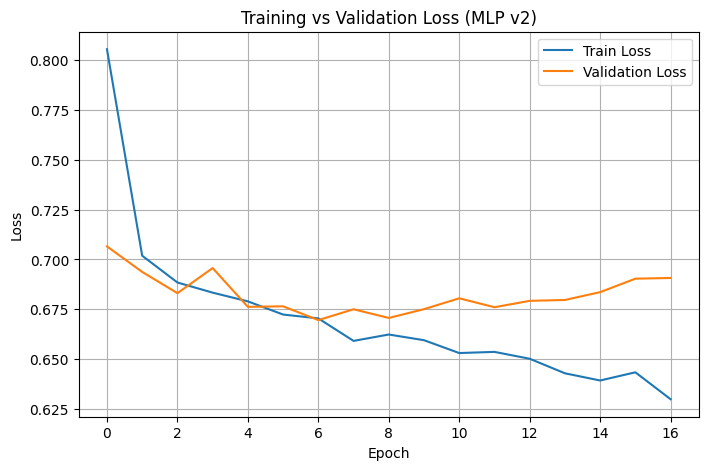

In [12]:
import matplotlib.pyplot as plt

epochs = range(len(train_losses_history))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses_history, label="Train Loss")
plt.plot(epochs, val_losses_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MLP v2)")
plt.legend()
plt.grid(True)

plt.show()


A curva de treino mostra queda consistente da loss, indicando que a rede aprendeu padrões relevantes.  
A loss de validação cai inicialmente e depois estabiliza, sem divergência expressiva em relação à loss de treino.

Isso sugere que o modelo apresenta boa generalização, com indícios apenas leves de overfitting, controlados pelo early stopping.

#### Avaliação técnica + negócio

In [13]:
def evaluate_predictions(y_true, y_proba, threshold, custo_fp, custo_fn):
    y_pred = (y_proba >= threshold).astype(int)

    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()

    custo_total = fp * custo_fp + fn * custo_fn
    valor_retido = tp * custo_fn
    valor_liquido = valor_retido - (fp * custo_fp)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_churn": precision_score(y_true, y_pred, zero_division=0),
        "recall_churn": recall_score(y_true, y_pred, zero_division=0),
        "f1_churn": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "tn": tn,
        "custo_total": custo_total,
        "valor_retido": valor_retido,
        "valor_liquido": valor_liquido,
    }

In [14]:
ticket_medio_churn = df.loc[df["Churn Value"] == 1, "Monthly Charges"].mean()
meses_retencao = 3

custo_fn = ticket_medio_churn * meses_retencao
custo_fp = 100

Em vez de usar automaticamente o threshold padrão de 0.5, testamos diferentes pontos de corte no conjunto de validação.

A escolha foi feita com base em valor líquido, considerando:
- falso positivo: cliente abordado desnecessariamente pela campanha;
- falso negativo: cliente que churnaria e não foi identificado;
- verdadeiro positivo: cliente de risco corretamente identificado.

In [15]:
model_v2.eval()

with torch.no_grad():
    val_logits = model_v2(X_val_tensor)
    val_proba = torch.sigmoid(val_logits).numpy().ravel()

thresholds = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for threshold in thresholds:
    metrics = evaluate_predictions(
        y_true=y_val.values,
        y_proba=val_proba,
        threshold=threshold,
        custo_fp=custo_fp,
        custo_fn=custo_fn,
    )
    metrics["threshold"] = threshold
    threshold_results.append(metrics)

df_thresholds = pd.DataFrame(threshold_results)

best_threshold = df_thresholds.sort_values(
    by="valor_liquido",
    ascending=False,
).iloc[0]["threshold"]

best_threshold

np.float64(0.6500000000000001)

In [16]:
with torch.no_grad():
    test_logits = model_v2(X_test_tensor)
    test_proba = torch.sigmoid(test_logits).numpy().ravel()

final_metrics = evaluate_predictions(
    y_true=y_test.values,
    y_proba=test_proba,
    threshold=best_threshold,
    custo_fp=custo_fp,
    custo_fn=custo_fn,
)

final_metrics

{'accuracy': 0.785781990521327,
 'precision_churn': 0.5813253012048193,
 'recall_churn': 0.6892857142857143,
 'f1_churn': 0.630718954248366,
 'roc_auc': 0.8501774193548386,
 'fp': np.int64(139),
 'fn': np.int64(87),
 'tp': np.int64(193),
 'tn': np.int64(636),
 'custo_total': np.float64(33329.187720706264),
 'valor_retido': np.float64(43101.531380417335),
 'valor_liquido': np.float64(29201.531380417335)}

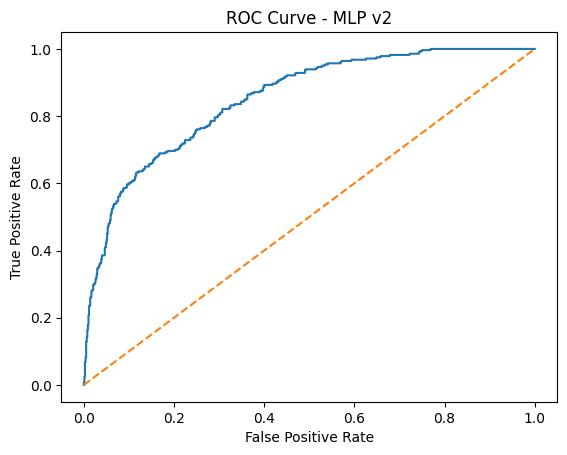

In [ ]:

fpr, tpr, _ = roc_curve(y_test, test_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve - MLP v2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

Embora o modelo anterior apresentasse maior recall, ele também gerava maior custo operacional devido ao elevado número de falsos positivos.

O modelo com feature engineering apresentou melhor equilíbrio entre precisão e recall, resultando em maior valor líquido e menor custo total, sendo portanto mais adequado para uso em produção.

#### Registrando o experimento + salvando os artefatos

In [17]:
mlflow.set_experiment("churn_mlp_feature_engineering")

if LOG_MLFLOW:
    with mlflow.start_run(run_name="mlp_v2_feature_engineering"):
        mlflow.log_param("model_name", "mlp_v2_feature_engineering")
        mlflow.log_param("random_state", RANDOM_STATE)
        mlflow.log_param("test_size", TEST_SIZE)
        mlflow.log_param("val_size", VAL_SIZE)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("epochs_max", epochs_max)
        mlflow.log_param("patience", patience)
        mlflow.log_param("hidden_layers", "128-64-32")
        mlflow.log_param("dropout", 0.3)
        mlflow.log_param("loss", "BCEWithLogitsLoss")
        mlflow.log_param("pos_weight", float(pos_weight.item()))
        mlflow.log_param("threshold", float(best_threshold))
        mlflow.log_param("custo_fp", custo_fp)
        mlflow.log_param("custo_fn", custo_fn)
        mlflow.log_param("meses_retencao", meses_retencao)

        for metric_name, metric_value in final_metrics.items():
            mlflow.log_metric(metric_name, float(metric_value))

        mlflow.log_metric("best_val_loss", best_val_loss)

        mlflow.pytorch.log_model(model_v2, "mlp_v2_model")

In [18]:
def convert_to_python_types(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj


if SAVE_ARTIFACTS:    
    torch.save(model_v2.state_dict(), MODELS_DIR / "mlp_churn_model_v2.pt")
    joblib.dump(preprocessor_v2, MODELS_DIR / "preprocessor_v2.pkl")

    metadata_v2 = {
        "model_name": "MLP v2 Feature Engineering",
        "target": "Churn Value",
        "threshold": float(best_threshold),
        "features": X_fe.columns.tolist(),
        "metrics": final_metrics,
        "feature_engineering": [
            "avg_charge_per_tenure",
            "is_month_to_month",
            "has_fiber",
            "has_tech_support",
            "has_online_security",
            "is_new_customer",
            "is_long_term_customer",
            "num_services",
            "charge_per_service",
        ],
    }

    with open(MODELS_DIR / "model_metadata_v2.json", "w", encoding="utf-8") as file:
        json.dump(metadata_v2, file, indent=4, default=convert_to_python_types)